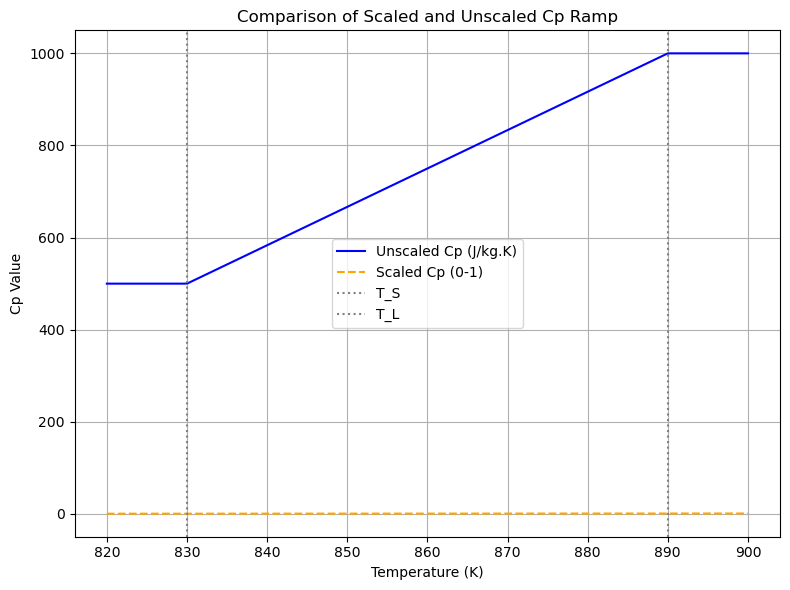

In [2]:
import torch
import matplotlib.pyplot as plt

# cp_ramp function with both scaled and unscaled outputs
def cp_ramp(temp, v1, v2, T_L, T_S):
    slope = (v1 - v2) / (T_L - T_S + 1e-8)
    cp_m = torch.where(temp > T_L, v1,
             torch.where(temp < T_S, v2,
             v2 + slope * (temp - T_S)))
    cp_max = torch.maximum(v1, v2)
    cp_m_sc = cp_m / (cp_max + 1e-8)  # Scaled version (0–1)
    return cp_m, cp_m_sc

# Physical Cp values (in J/kg.K)
cp_l = torch.tensor(1000.0)  # Liquid phase
cp_s = torch.tensor(500.0)   # Solid phase

# Mushy zone temperature range
T_S = torch.tensor(830.0)
T_L = torch.tensor(890.0)
temps = torch.linspace(820, 900, 200)

# Get both scaled and unscaled Cp
cp_unscaled, cp_scaled = cp_ramp(temps, cp_l, cp_s, T_L, T_S)

# Plot both
plt.figure(figsize=(8, 6))
plt.plot(temps, cp_unscaled, label='Unscaled Cp (J/kg.K)', color='blue')
plt.plot(temps, cp_scaled, label='Scaled Cp (0-1)', color='orange', linestyle='--')
plt.axvline(x=830, color='gray', linestyle=':', label='T_S')
plt.axvline(x=890, color='gray', linestyle=':', label='T_L')
plt.xlabel("Temperature (K)")
plt.ylabel("Cp Value")
plt.title("Comparison of Scaled and Unscaled Cp Ramp")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

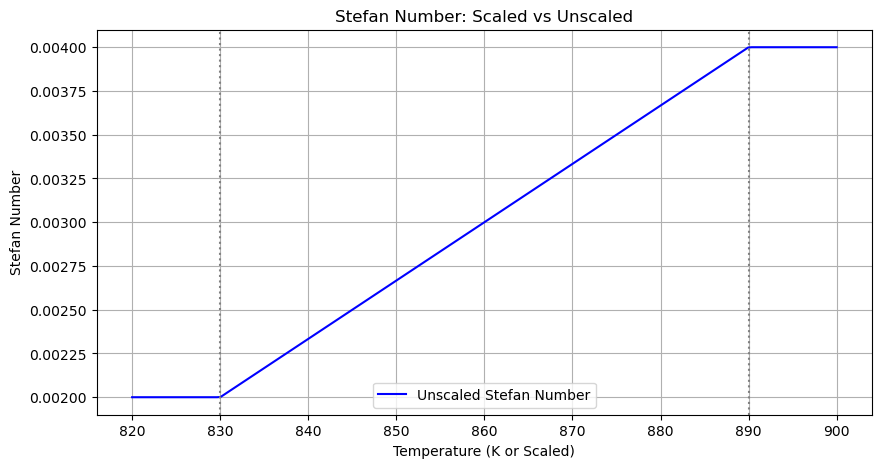

In [5]:
import torch
import matplotlib.pyplot as plt

# Cp ramp function
def cp_ramp(temp, v1, v2, T_L, T_S):
    slope = (v1 - v2) / (T_L - T_S)
    cp_m = torch.where(temp > T_L, v1,
             torch.where(temp < T_S, v2,
             v2 + slope * (temp - T_S)))
    cp_max = torch.maximum(v1, v2)
    cp_m_sc = cp_m / cp_max
    return cp_m, cp_m_sc

# Stefan number function
def stefan_number(cp, delta_T, L_fusion):
    return (cp * delta_T) / L_fusion

# Unscaled version
cp_l, cp_s = torch.tensor(1000.0), torch.tensor(500.0)
L_fusion = torch.tensor(250000.0)
T_S, T_L = 830.0, 890.0
temps_unscaled = torch.linspace(820, 900, 200)
delta_T_unscaled = T_L - T_S

cp_u, _ = cp_ramp(temps_unscaled, cp_l, cp_s, T_L, T_S)
Ste_unscaled = stefan_number(cp_u, delta_T_unscaled, L_fusion)

# Scaled version
cp_l_s, cp_s_s = torch.tensor(1.0), torch.tensor(0.5)
L_fusion_s = torch.tensor(1.0)
T_S_s, T_L_s = 0.0, 1.0
temps_scaled = torch.linspace(0.0, 1.0, 200)
delta_T_scaled = T_L_s - T_S_s

_, cp_scaled = cp_ramp(temps_scaled, cp_l_s, cp_s_s, T_L_s, T_S_s)
Ste_scaled = stefan_number(cp_scaled, delta_T_scaled, L_fusion_s)
Ste_unscaled = stefan_number(cp_u, delta_T_scaled, L_fusion)
# Plotting
plt.figure(figsize=(10, 5))
plt.plot(temps_unscaled.numpy(), Ste_unscaled.numpy(), label='Unscaled Stefan Number', color='blue')
# plt.plot(torch.linspace(830, 890, 200).numpy(), Ste_scaled.numpy(), label='Scaled Stefan Number', color='orange', linestyle='--')
plt.axvline(x=830, color='gray', linestyle=':')
plt.axvline(x=890, color='gray', linestyle=':')
plt.xlabel("Temperature (K or Scaled)")
plt.ylabel("Stefan Number")
plt.title("Stefan Number: Scaled vs Unscaled")
plt.legend()
plt.grid(True)
plt.show()

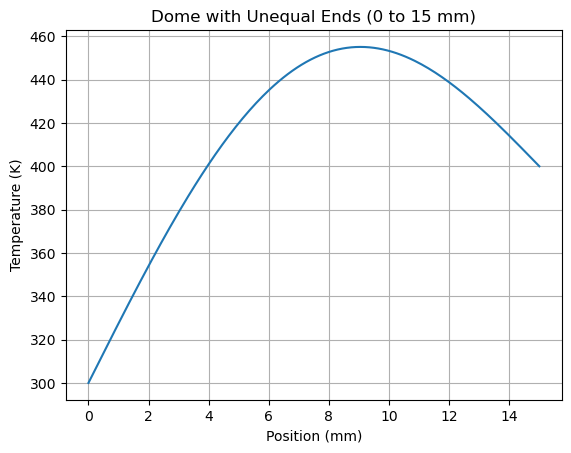

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_points = 200
L = 15e-3  # 15 mm
x = np.linspace(0, L, num_points)

T_left = 300  # K
T_right = 400  # K
A = 100        # Amplitude of dome bulge

# Dome with unequal ends
linear_part = T_left + (T_right - T_left) * (x / L)
sine_dome = A * np.sin(np.pi * x / L)
temp_profile = linear_part + sine_dome

# Plot
plt.plot(x * 1000, temp_profile)
plt.title("Dome with Unequal Ends (0 to 15 mm)")
plt.xlabel("Position (mm)")
plt.ylabel("Temperature (K)")
plt.grid(True)
plt.show()